# Comparison of L-NODEC Policies with Different κ (Kappa) Values

This notebook loads pre-trained L-NODEC policies with different exponential stability rates (κ) and compares their performance.

**Key Aspects Analyzed:**
- Control performance (trajectory tracking)
- Constraint satisfaction (temperature limits)
- Convergence speed (time to reach target)
- Robustness to initial condition perturbations
- Control effort (energy consumption)

**Kappa (κ) Parameter:**
- Controls the exponential convergence rate in the Lyapunov condition: `dV/dt ≤ -κV`
- Higher κ → faster convergence but potentially more aggressive control
- Lower κ → slower convergence but potentially smoother control

## Setup and Imports

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import os
from typing import Dict, List, Tuple

# Import L-NODEC modules
from policy import NeuralPolicy
from lyapunov import QuadraticLyapunov
from loss import LyapunovLoss
from simulator import Simulator
from trainer import LNODECTrainer
from systems import plasma_dynamics
from cost import TerminalCost
from nodec_trainer import NODECTrainer
from constraints import ConstraintHandler
from samplers import NormalSetToPointSampler
from visualization import set_plot_style, COLORS

# Apply publication-quality plotting style
set_plot_style()

# Set device and precision
device = torch.device("cpu")
dtype = torch.float64

print("Modules loaded successfully!")

Modules loaded successfully!


## System Configuration

In [2]:
# System parameters (must match training configuration)
state_dim = 2  # [Temperature (°C), CEM (min)]
control_dim = 1  # [Power (W)]
u_min = 1.0  # Minimum power (W)
u_max = 5.0  # Maximum power (W)

# Temperature conversion
k2cel = 273.15
T_up = 318.15  # 45°C

# Initial condition and target
x0 = torch.tensor([310.15 - k2cel, 0.0], dtype=dtype, device=device)  # [37°C, 0 min]
z_target = torch.tensor([T_up - k2cel, 1.5], dtype=dtype, device=device)  # [45°C, 1.5 min]

# Normalization factor (for temperature only)
normalization_factor = 40.0

def normalize_state(x):
    """Normalize temperature component for better neural network training"""
    y = x.clone()
    if len(y.shape) != 1:
        y[..., 0] = y[..., 0] / normalization_factor
    else:
        y[0] = y[0] / normalization_factor
    return y

# Time discretization
t_final = 100.0
num_steps = 500
time_grid = torch.linspace(0, t_final, num_steps, dtype=dtype, device=device)

# Lyapunov/Cost matrix P
P_diag = [1e-6, 1.0]  # [Temperature weight, CEM weight]
P = torch.diag(torch.tensor(P_diag, dtype=dtype, device=device))

# Temperature constraint
T_max = T_up - k2cel  # 45°C

print(f"System configured:")
print(f"  Initial state: {x0.numpy()} [°C, min]")
print(f"  Target state: {z_target.numpy()} [°C, min]")
print(f"  Temperature constraint: T ≤ {T_max}°C")

System configured:
  Initial state: [37.  0.] [°C, min]
  Target state: [45.   1.5] [°C, min]
  Temperature constraint: T ≤ 45.0°C


## Find Available Trained Policies

In [3]:
# Search for available .pt files
import glob

# Define the patterns for different policy types
patterns = {
    'L-NODEC': 'results_plasma_lnodec_unconstrained_kappa*.pt',
    'L-NODEC-Constrained': 'results_plasma_lnodec_constrained_kappa*.pt',
    'NODEC-Terminal': 'results_plasma_nodec_terminal_kappa*.pt'
}

def parse_kappa_from_filename(filename):
    """Parse kappa value from filename, handling both integer and decimal formats."""
    import re
    # Match patterns like kappa1, kappa0p1, kappa2p5, etc.
    match = re.search(r'kappa([0-9]+(?:p[0-9]+)?)', filename)
    if match:
        kappa_str = match.group(1)
        # Replace 'p' with '.' to convert back to decimal
        kappa_str = kappa_str.replace('p', '.')
        try:
            # Try to parse as float first
            kappa = float(kappa_str)
            # If it's a whole number, convert to int for cleaner display
            if kappa.is_integer():
                kappa = int(kappa)
            return kappa
        except ValueError:
            return None
    return None

available_policies = {}

for policy_type, pattern in patterns.items():
    files = glob.glob(pattern)
    if files:
        available_policies[policy_type] = {}
        for file in files:
            # Extract kappa value from filename
            kappa = parse_kappa_from_filename(file)
            if kappa is not None:
                available_policies[policy_type][kappa] = file
            else:
                # Try to load the file and get kappa from checkpoint
                try:
                    checkpoint = torch.load(file, map_location='cpu')
                    if 'kappa' in checkpoint:
                        kappa = checkpoint['kappa']
                        available_policies[policy_type][kappa] = file
                except:
                    pass

print("Available trained policies:")
for policy_type, kappa_files in available_policies.items():
    print(f"\n{policy_type}:")
    for kappa, filepath in sorted(kappa_files.items()):
        if os.path.exists(filepath):
            file_size = os.path.getsize(filepath) / 1024  # KB
            print(f"  κ={kappa}: {filepath} ({file_size:.1f} KB)")

# Determine which kappa values are available across all methods
all_kappas = set()
for policy_type in available_policies:
    all_kappas.update(available_policies[policy_type].keys())

common_kappas = sorted(all_kappas)
print(f"\nKappa values to compare: {common_kappas}")

Available trained policies:

L-NODEC:
  κ=0.001: results_plasma_lnodec_unconstrained_kappa0p001.pt (20.2 KB)
  κ=0.1: results_plasma_lnodec_unconstrained_kappa0p1.pt (20.2 KB)
  κ=1: results_plasma_lnodec_unconstrained_kappa1.pt (20.1 KB)
  κ=2: results_plasma_lnodec_unconstrained_kappa2.pt (20.1 KB)

L-NODEC-Constrained:
  κ=0.001: results_plasma_lnodec_constrained_kappa0p001.pt (20.3 KB)
  κ=0.1: results_plasma_lnodec_constrained_kappa0p1.pt (20.2 KB)
  κ=1: results_plasma_lnodec_constrained_kappa1.pt (20.0 KB)
  κ=2: results_plasma_lnodec_constrained_kappa2.pt (20.0 KB)

NODEC-Terminal:
  κ=0.001: results_plasma_nodec_terminal_kappa0p001.pt (16.2 KB)
  κ=0.1: results_plasma_nodec_terminal_kappa0p1.pt (16.1 KB)
  κ=1: results_plasma_nodec_terminal_kappa1.pt (15.9 KB)
  κ=2: results_plasma_nodec_terminal_kappa2.pt (15.9 KB)

Kappa values to compare: [0.001, 0.1, 1, 2]


## Load and Evaluate Policies

In [4]:
def load_policy(filepath: str, policy_type: str, kappa: float):
    """Load a trained policy from file."""
    
    # Create policy architecture (must match training)
    policy = NeuralPolicy(
        state_dim=state_dim,
        control_dim=control_dim,
        hidden_dims=[32, 32],
        u_min=u_min,
        u_max=u_max,
        normalize_fn=normalize_state,
    ).to(device=device, dtype=dtype)
    
    # Load trained weights
    checkpoint = torch.load(filepath, map_location=device)
    policy.load_state_dict(checkpoint['policy_state_dict'])
    
    # Extract training history if available
    history = checkpoint.get('history', None)
    
    return policy, history


def evaluate_policy(policy, x0, z_target, time_grid):
    """Evaluate a policy and return trajectory and controls."""
    
    # Create simulator
    simulator = Simulator(
        dynamics_fn=plasma_dynamics,
        method="rk4",
        rtol=1e-6,
        atol=1e-8,
    )
    
    # Generate trajectory
    with torch.no_grad():
        trajectory, controls = simulator.rollout(
            x0=x0, 
            policy=policy, 
            time_grid=time_grid,
            adjoint=False
        )
    
    return trajectory.cpu().numpy(), controls.cpu().numpy()


# Load all available policies
loaded_policies = {}
trajectories = {}
controls = {}
histories = {}

for policy_type, kappa_files in available_policies.items():
    loaded_policies[policy_type] = {}
    trajectories[policy_type] = {}
    controls[policy_type] = {}
    histories[policy_type] = {}
    
    for kappa, filepath in kappa_files.items():
        print(f"Loading {policy_type} with κ={kappa}...")
        try:
            policy, history = load_policy(filepath, policy_type, kappa)
            loaded_policies[policy_type][kappa] = policy
            histories[policy_type][kappa] = history
            
            # Evaluate policy
            traj, ctrl = evaluate_policy(policy, x0, z_target, time_grid)
            trajectories[policy_type][kappa] = traj
            controls[policy_type][kappa] = ctrl
            
            # Compute final distance
            final_dist = np.linalg.norm(traj[-1] - z_target.numpy())
            max_temp = traj[:, 0].max()
            print(f"  ✓ Final distance: {final_dist:.4f}, Max temp: {max_temp:.2f}°C")
            
        except Exception as e:
            print(f"  ✗ Error loading: {e}")

print("\nAll policies loaded and evaluated!")

Loading L-NODEC with κ=2...
  ✓ Final distance: 9.1837, Max temp: 46.71°C
Loading L-NODEC with κ=0.001...
  ✓ Final distance: 9.1817, Max temp: 46.53°C
Loading L-NODEC with κ=0.1...
  ✓ Final distance: 9.1826, Max temp: 46.66°C
Loading L-NODEC with κ=1...
  ✓ Final distance: 9.1837, Max temp: 46.70°C
Loading L-NODEC-Constrained with κ=1...
  ✓ Final distance: 5.7856, Max temp: 45.00°C
Loading L-NODEC-Constrained with κ=0.1...
  ✓ Final distance: 6.0376, Max temp: 41.70°C
Loading L-NODEC-Constrained with κ=2...
  ✓ Final distance: 5.9339, Max temp: 45.07°C
Loading L-NODEC-Constrained with κ=0.001...
  ✓ Final distance: 6.4101, Max temp: 39.87°C
Loading NODEC-Terminal with κ=1...
  ✓ Final distance: 9.1787, Max temp: 46.67°C
Loading NODEC-Terminal with κ=0.001...
  ✓ Final distance: 9.1787, Max temp: 46.67°C
Loading NODEC-Terminal with κ=2...
  ✓ Final distance: 9.1787, Max temp: 46.67°C
Loading NODEC-Terminal with κ=0.1...
  ✓ Final distance: 9.1787, Max temp: 46.67°C

All policies load

## Performance Metrics Computation

In [5]:
def compute_metrics(trajectory, controls, x0, z_target, time_grid, T_max):
    """Compute performance metrics for a trajectory."""
    
    metrics = {}
    
    # Final distance to target
    metrics['final_distance'] = np.linalg.norm(trajectory[-1] - z_target.numpy())
    
    # Maximum temperature
    metrics['max_temperature'] = trajectory[:, 0].max()
    
    # Temperature constraint violation
    metrics['temp_violation'] = max(0, metrics['max_temperature'] - T_max)
    
    # Time to reach within 10% of target (settling time)
    target_norm = np.linalg.norm(z_target.numpy() - x0.numpy())
    distances = np.linalg.norm(trajectory - z_target.numpy(), axis=1)
    settled_mask = distances < 0.1 * target_norm
    if settled_mask.any():
        metrics['settling_time'] = time_grid[settled_mask].min().item()
    else:
        metrics['settling_time'] = float('inf')
    
    # Control effort (integral of u^2)
    dt = time_grid[1] - time_grid[0]
    metrics['control_effort'] = float(dt * (controls**2).sum())
    
    # Average control magnitude
    metrics['avg_control'] = controls.mean()
    
    # Control variation (smoothness)
    metrics['control_variation'] = np.sum(np.abs(np.diff(controls.flatten())))
    
    # Final CEM (thermal dose)
    metrics['final_cem'] = trajectory[-1, 1]
    
    return metrics

# Compute metrics for all policies
all_metrics = {}

for policy_type in trajectories:
    all_metrics[policy_type] = {}
    
    for kappa in trajectories[policy_type]:
        traj = trajectories[policy_type][kappa]
        ctrl = controls[policy_type][kappa]
        
        metrics = compute_metrics(traj, ctrl, x0, z_target, time_grid, T_max)
        all_metrics[policy_type][kappa] = metrics

# Display metrics in a table
print("Performance Metrics Summary:\n")
print("-" * 100)

for policy_type in all_metrics:
    print(f"\n{policy_type}:")
    print(f"{'κ':<5} {'Final Dist':<12} {'Max Temp':<10} {'Violation':<10} {'Settling':<10} {'Control':<10} {'Smoothness':<10}")
    print("-" * 80)
    
    for kappa in sorted(all_metrics[policy_type].keys()):
        m = all_metrics[policy_type][kappa]
        print(f"{kappa:<5} {m['final_distance']:<12.4f} {m['max_temperature']:<10.2f} "
              f"{m['temp_violation']:<10.3f} {m['settling_time']:<10.2f} "
              f"{m['control_effort']:<10.2f} {m['control_variation']:<10.2f}")

Performance Metrics Summary:

----------------------------------------------------------------------------------------------------

L-NODEC:
κ     Final Dist   Max Temp   Violation  Settling   Control    Smoothness
--------------------------------------------------------------------------------
0.001 9.1817       46.53      1.527      18.44      510.20     4.00      
0.1   9.1826       46.66      1.659      19.24      527.19     3.99      
1     9.1837       46.70      1.704      19.24      527.59     3.99      
2     9.1837       46.71      1.708      19.24      527.83     3.99      

L-NODEC-Constrained:
κ     Final Dist   Max Temp   Violation  Settling   Control    Smoothness
--------------------------------------------------------------------------------
0.001 6.4101       39.87      0.000      inf        484.58     0.51      
0.1   6.0376       41.70      0.000      inf        633.16     1.11      
1     5.7856       45.00      0.005      22.04      899.11     2.55      
2     5.9

## Visualization: Trajectory Comparison

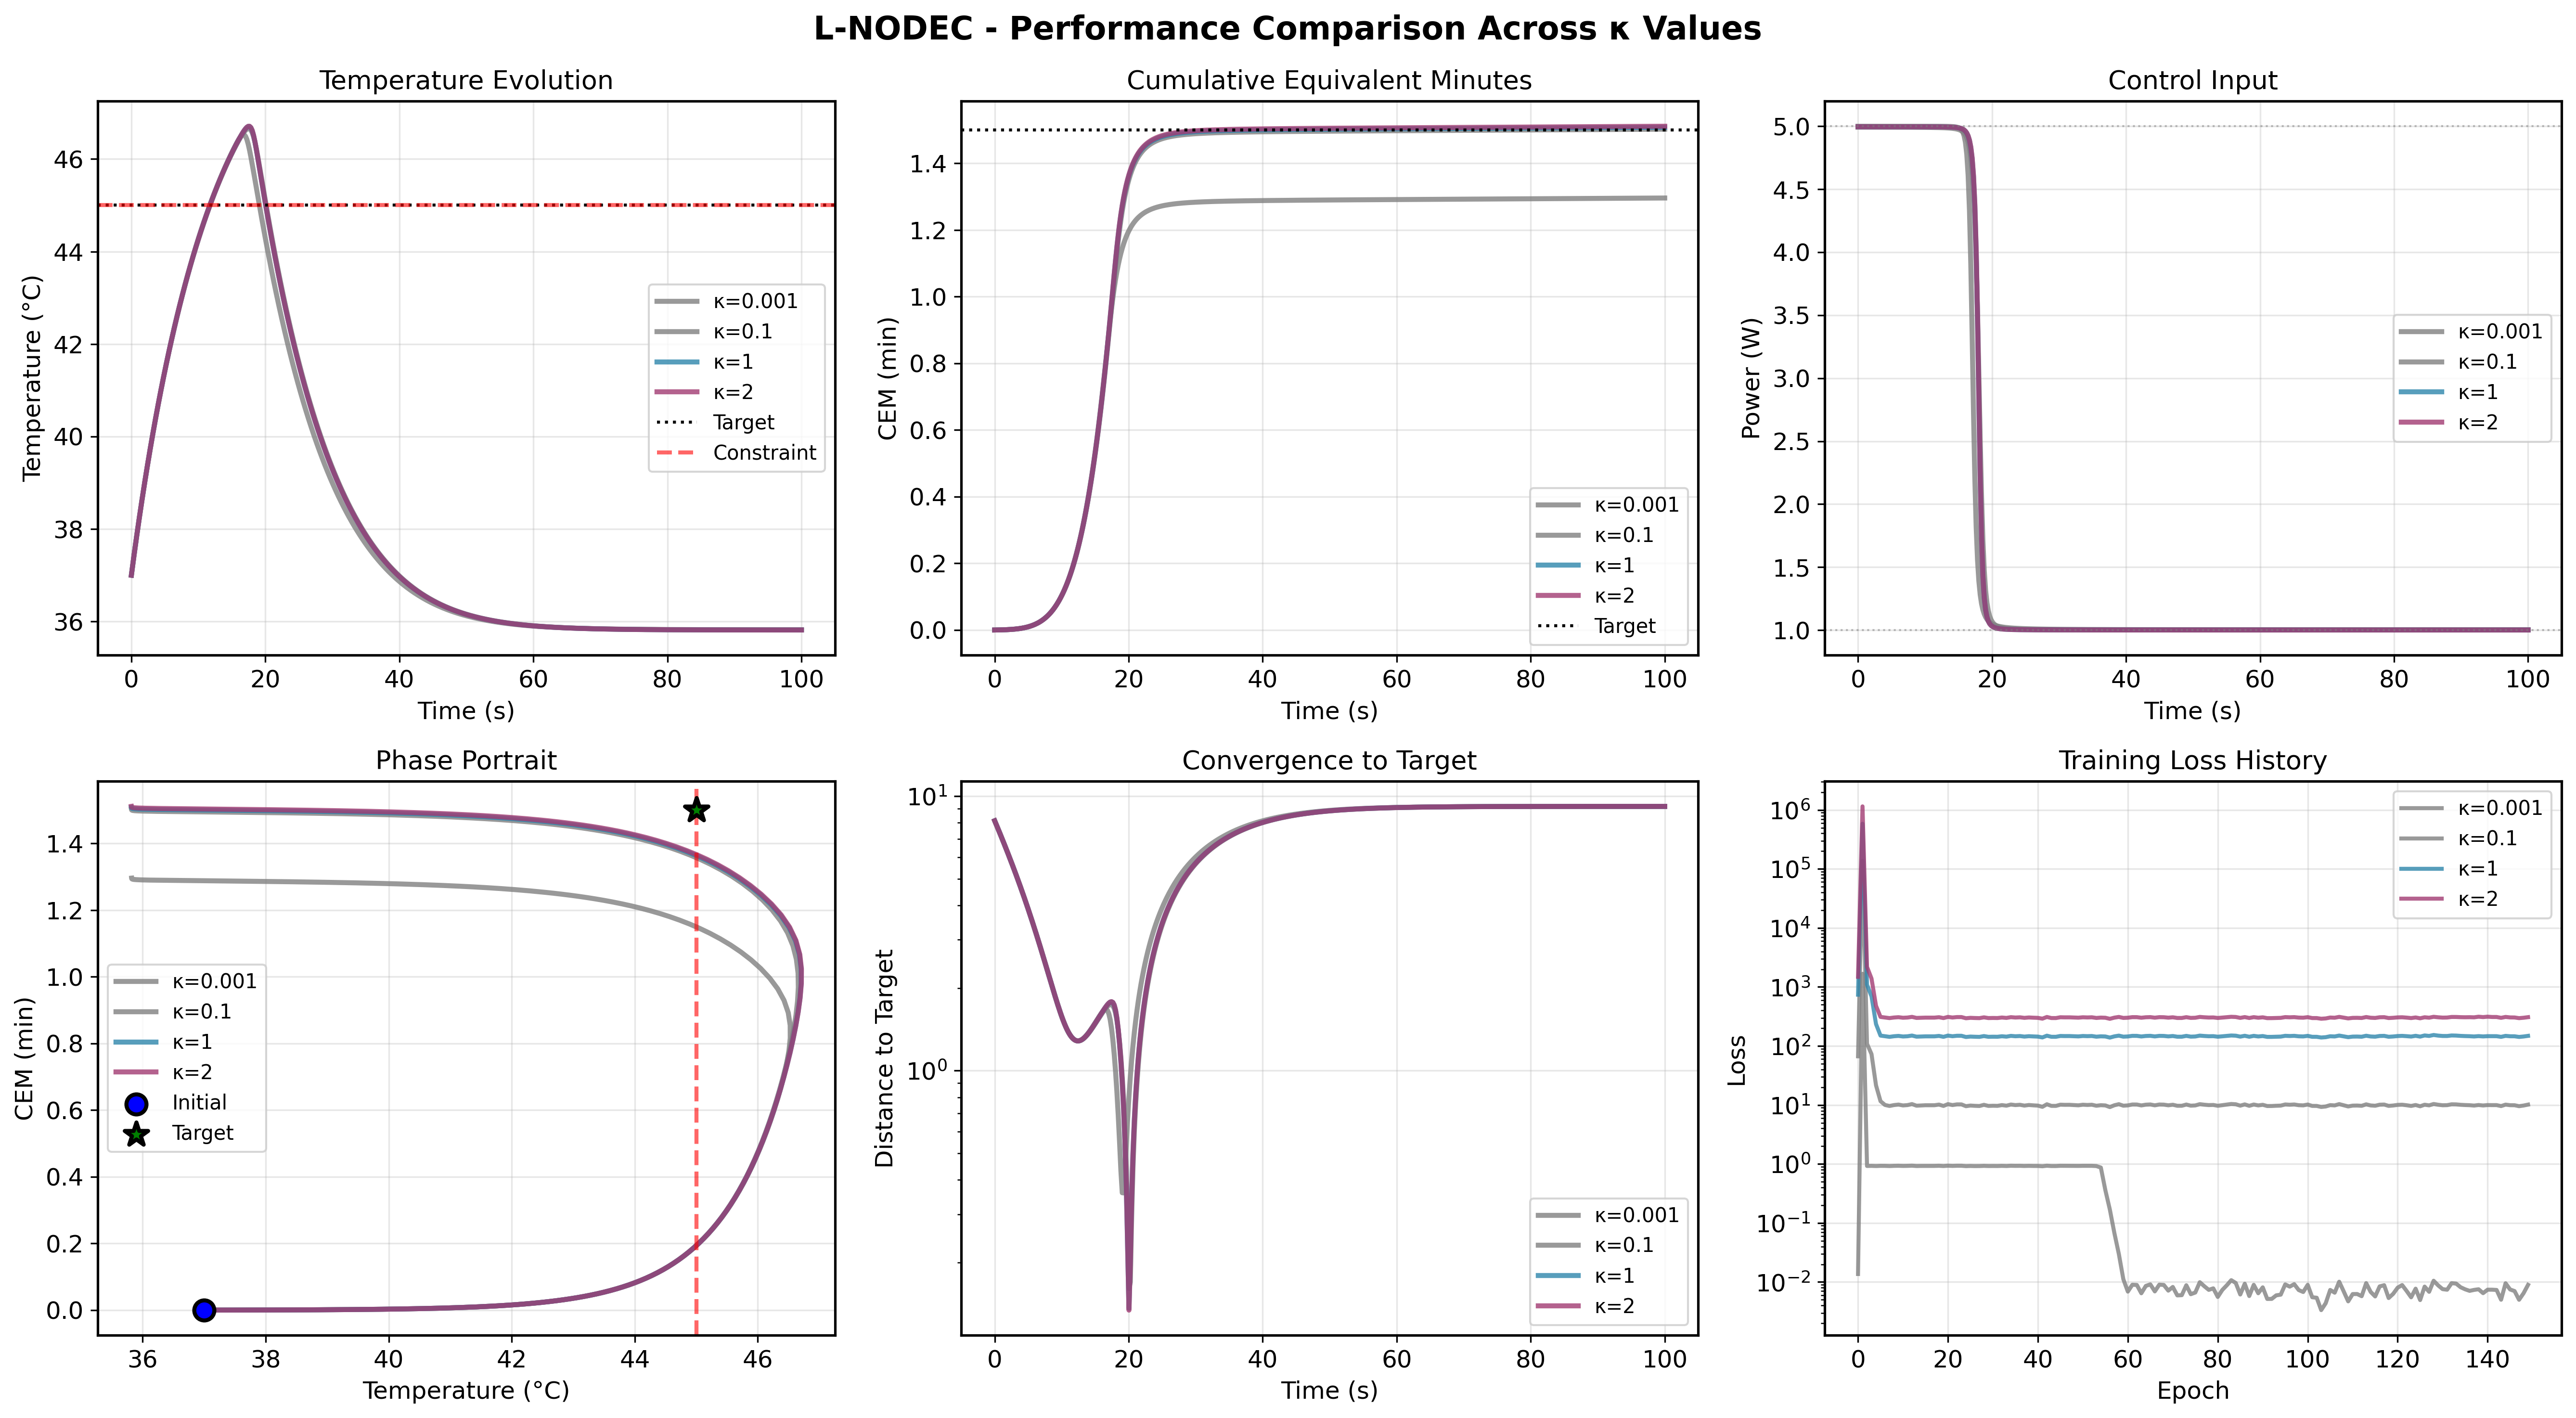

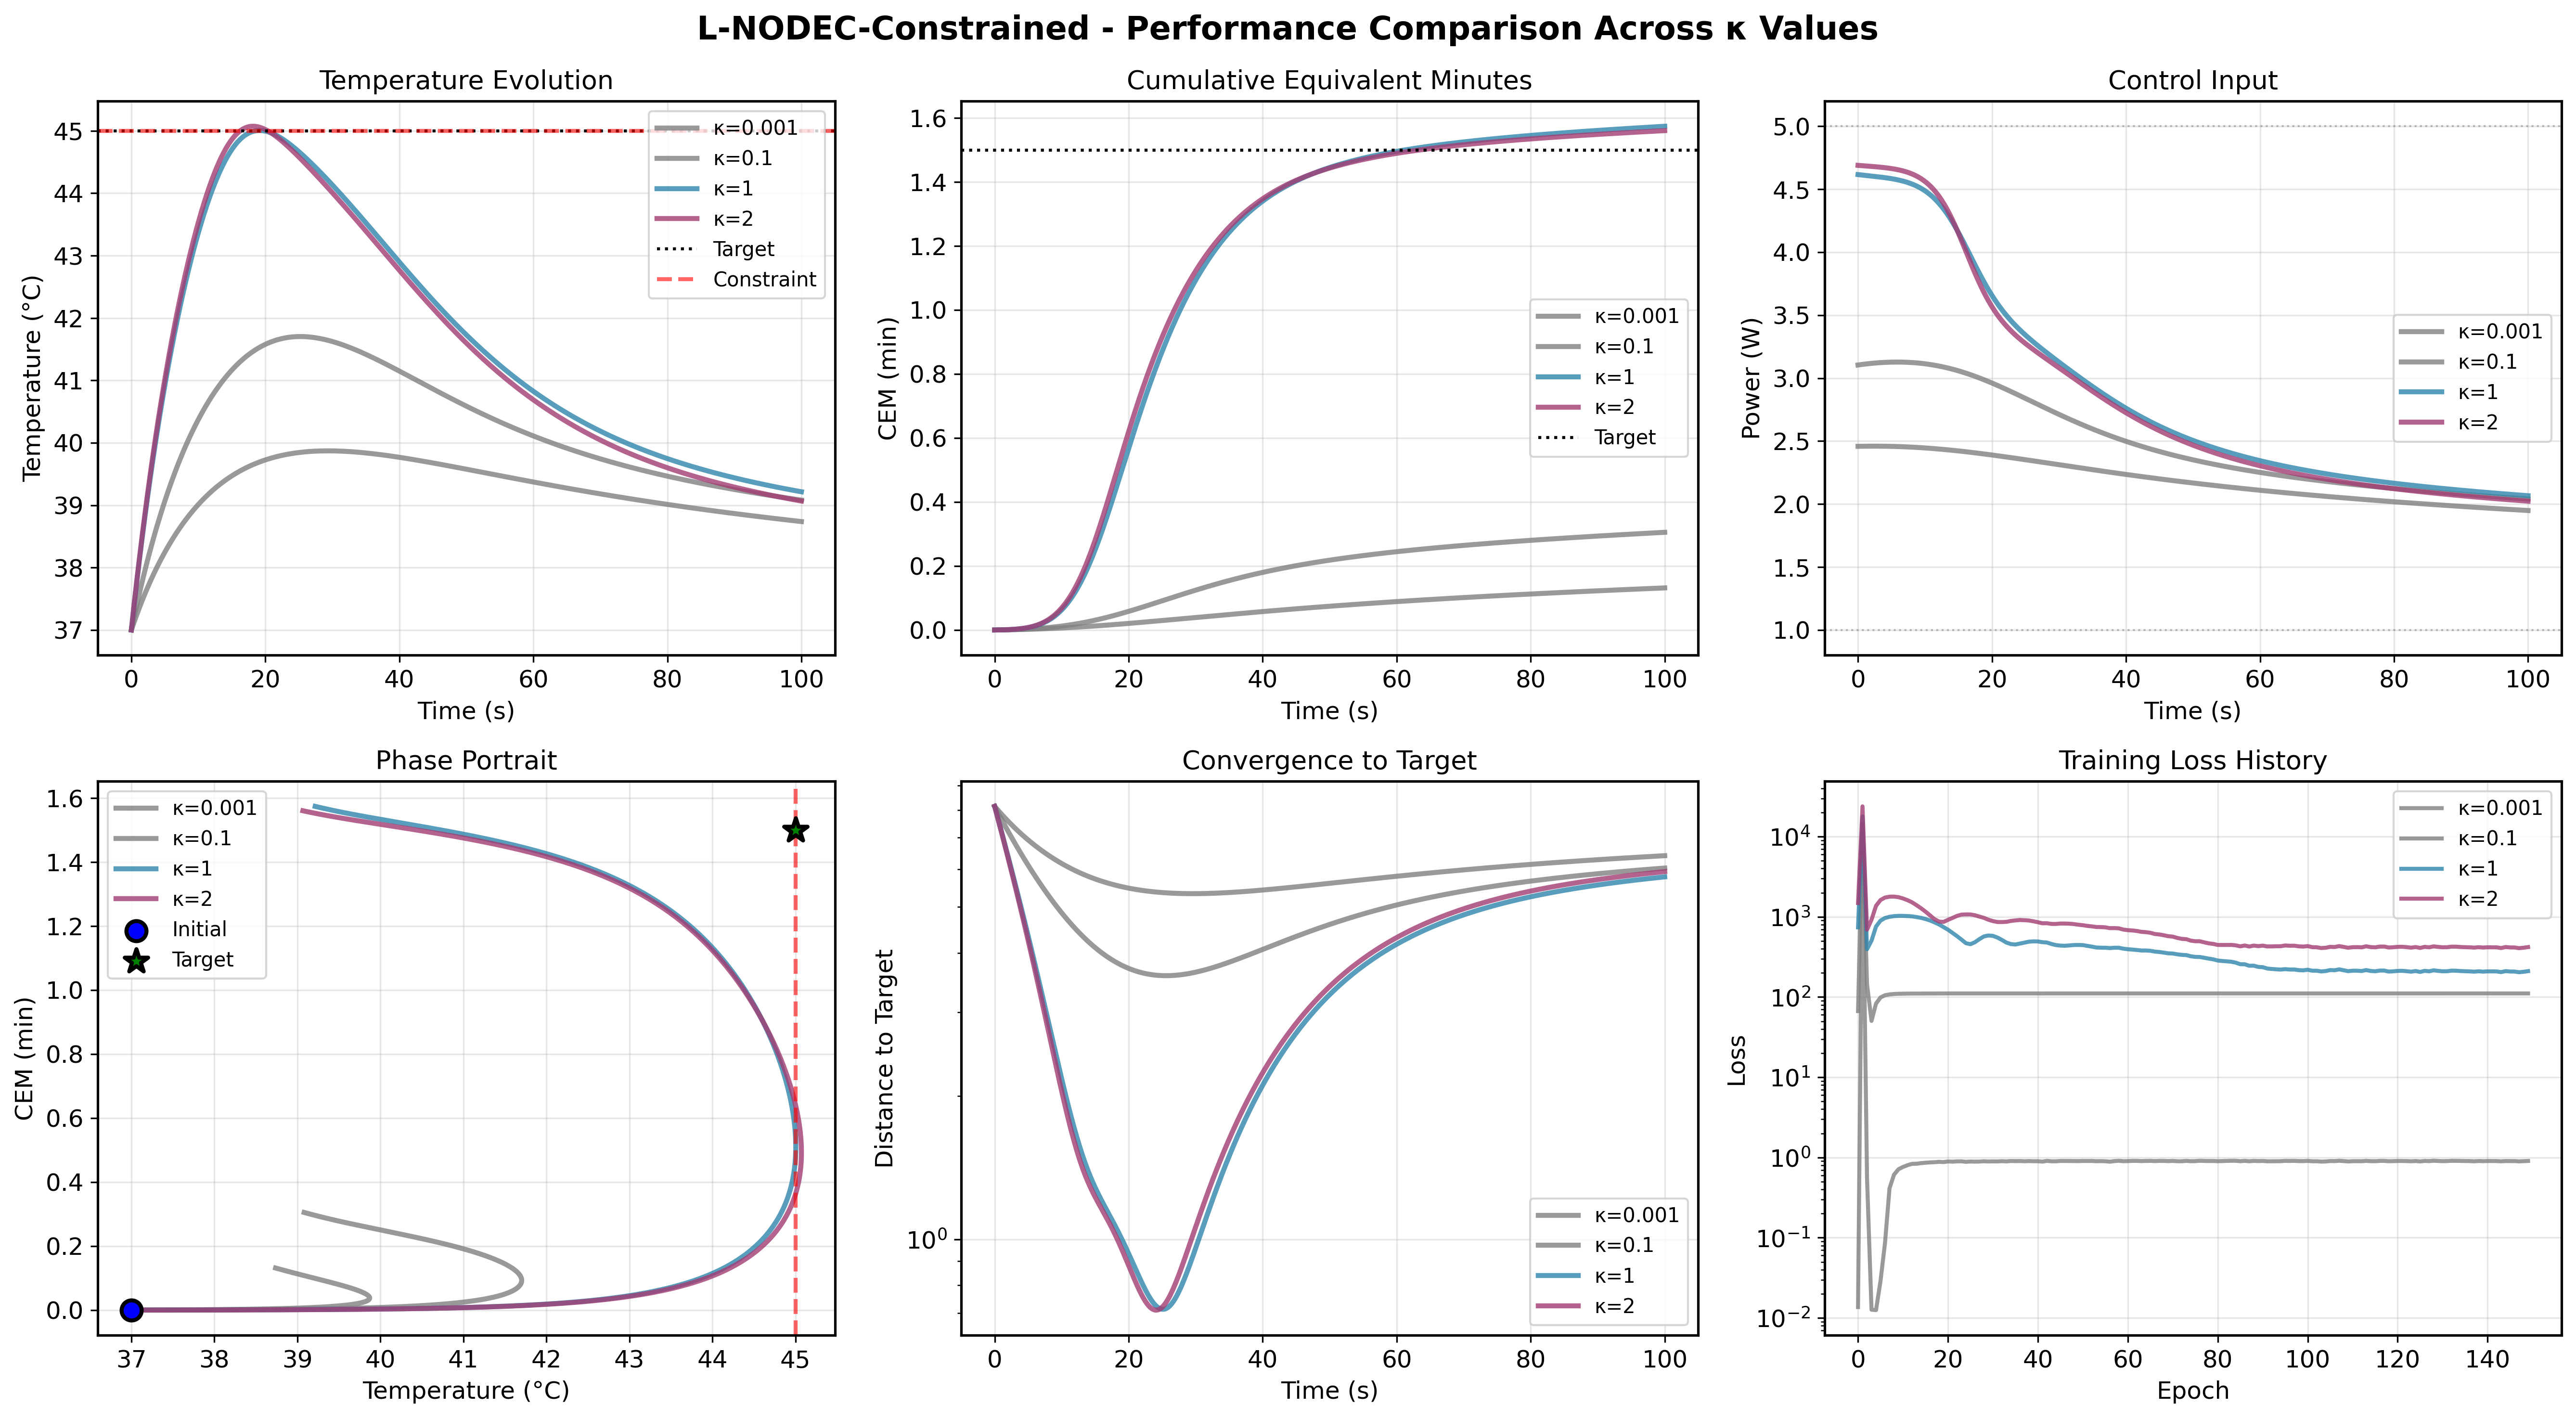

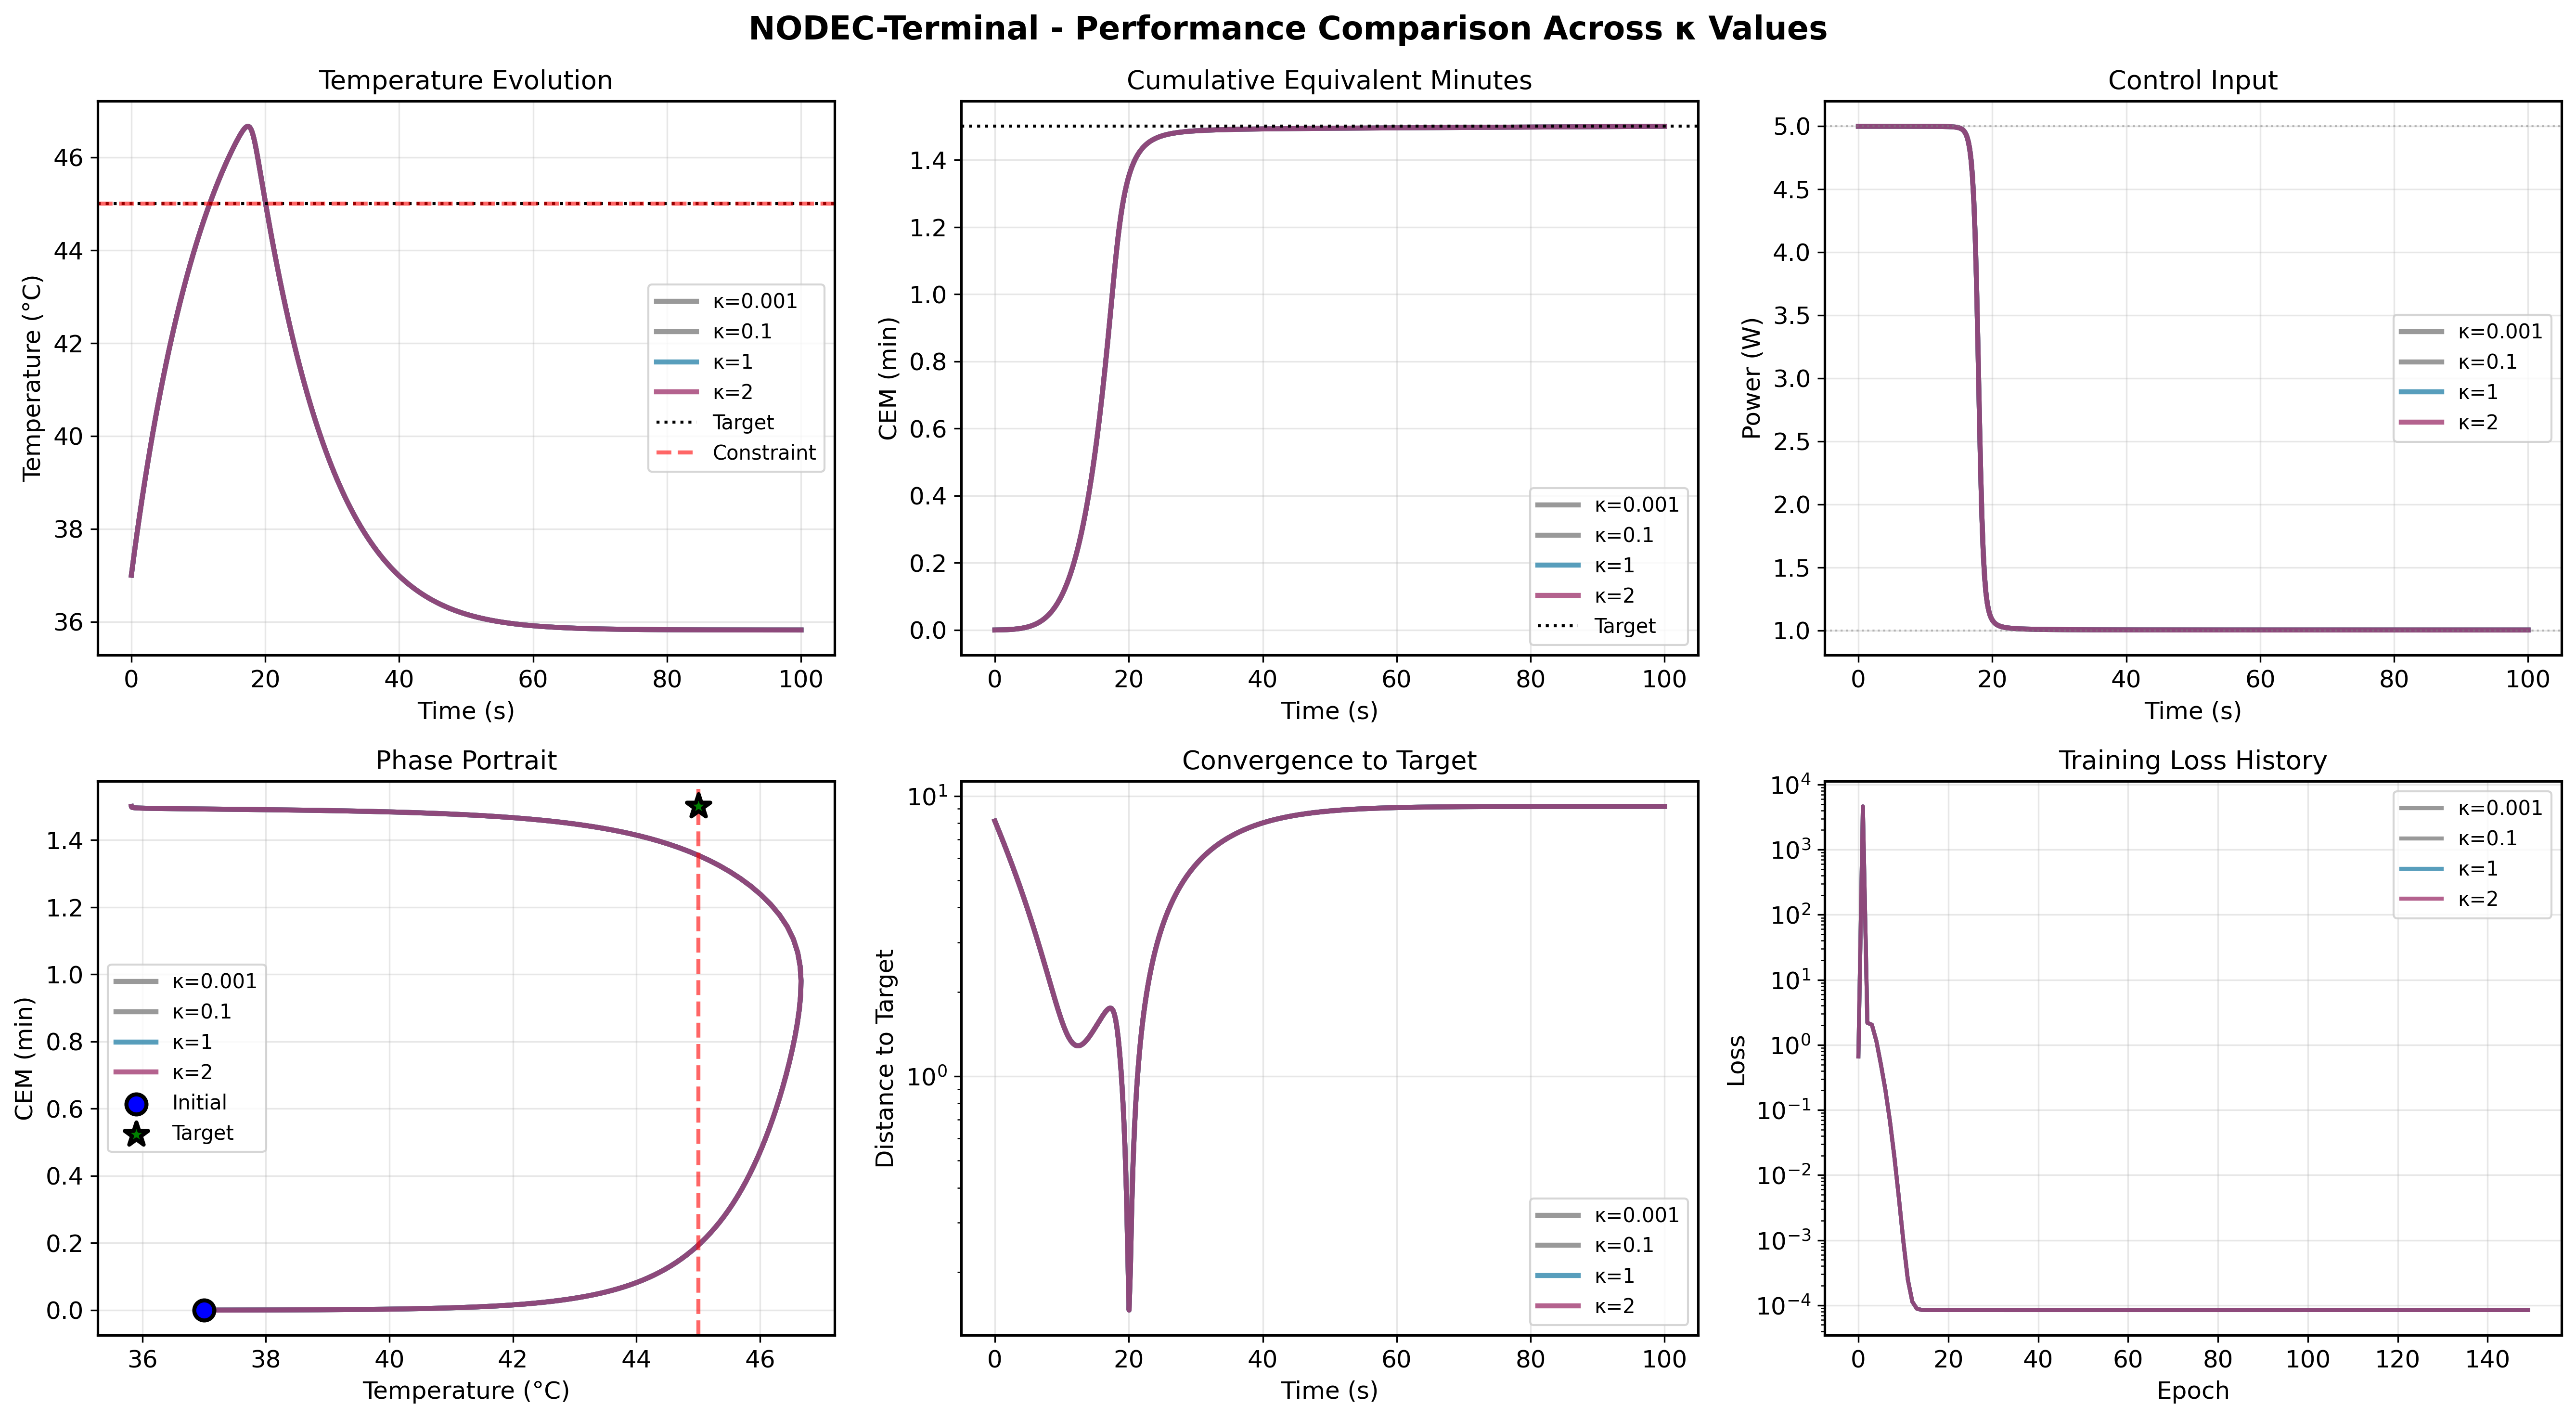

In [6]:
# Create comprehensive comparison plots
time_np = time_grid.cpu().numpy()

# Color scheme for different kappa values
kappa_colors = {
    1: '#2E86AB',  # Blue
    2: '#A23B72',  # Purple
    5: '#F18F01',  # Orange
    10: '#C73E1D'  # Red
}

for policy_type in trajectories:
    if not trajectories[policy_type]:
        continue
        
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle(f'{policy_type} - Performance Comparison Across κ Values', fontsize=16, fontweight='bold')
    
    kappas = sorted(trajectories[policy_type].keys())
    
    # Plot 1: Temperature trajectory
    ax = axes[0, 0]
    for kappa in kappas:
        traj = trajectories[policy_type][kappa]
        color = kappa_colors.get(kappa, 'gray')
        ax.plot(time_np, traj[:, 0], linewidth=2.5, label=f'κ={kappa}', color=color, alpha=0.8)
    
    ax.axhline(z_target[0].item(), color='black', linestyle=':', linewidth=1.5, label='Target')
    ax.axhline(T_max, color='red', linestyle='--', linewidth=2, label='Constraint', alpha=0.6)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Temperature (°C)', fontsize=12)
    ax.set_title('Temperature Evolution', fontsize=13)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Plot 2: CEM (thermal dose)
    ax = axes[0, 1]
    for kappa in kappas:
        traj = trajectories[policy_type][kappa]
        color = kappa_colors.get(kappa, 'gray')
        ax.plot(time_np, traj[:, 1], linewidth=2.5, label=f'κ={kappa}', color=color, alpha=0.8)
    
    ax.axhline(z_target[1].item(), color='black', linestyle=':', linewidth=1.5, label='Target')
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('CEM (min)', fontsize=12)
    ax.set_title('Cumulative Equivalent Minutes', fontsize=13)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Plot 3: Control input
    ax = axes[0, 2]
    for kappa in kappas:
        ctrl = controls[policy_type][kappa]
        color = kappa_colors.get(kappa, 'gray')
        ax.plot(time_np, ctrl, linewidth=2.5, label=f'κ={kappa}', color=color, alpha=0.8)
    
    ax.axhline(u_min, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.axhline(u_max, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Power (W)', fontsize=12)
    ax.set_title('Control Input', fontsize=13)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Plot 4: Phase portrait
    ax = axes[1, 0]
    for kappa in kappas:
        traj = trajectories[policy_type][kappa]
        color = kappa_colors.get(kappa, 'gray')
        ax.plot(traj[:, 0], traj[:, 1], linewidth=2.5, label=f'κ={kappa}', color=color, alpha=0.8)
    
    ax.scatter(x0[0].item(), x0[1].item(), color='blue', s=100, marker='o', 
              edgecolors='black', linewidth=2, zorder=5, label='Initial')
    ax.scatter(z_target[0].item(), z_target[1].item(), color='green', s=150, marker='*',
              edgecolors='black', linewidth=2, zorder=5, label='Target')
    ax.axvline(T_max, color='red', linestyle='--', linewidth=2, alpha=0.6)
    ax.set_xlabel('Temperature (°C)', fontsize=12)
    ax.set_ylabel('CEM (min)', fontsize=12)
    ax.set_title('Phase Portrait', fontsize=13)
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Plot 5: Distance to target over time
    ax = axes[1, 1]
    for kappa in kappas:
        traj = trajectories[policy_type][kappa]
        distances = np.linalg.norm(traj - z_target.numpy(), axis=1)
        color = kappa_colors.get(kappa, 'gray')
        ax.plot(time_np, distances, linewidth=2.5, label=f'κ={kappa}', color=color, alpha=0.8)
    
    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Distance to Target', fontsize=12)
    ax.set_title('Convergence to Target', fontsize=13)
    ax.set_yscale('log')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Plot 6: Training loss history (if available)
    ax = axes[1, 2]
    for kappa in kappas:
        if kappa in histories[policy_type] and histories[policy_type][kappa]:
            history = histories[policy_type][kappa]
            if 'loss' in history:
                color = kappa_colors.get(kappa, 'gray')
                ax.plot(history['loss'], linewidth=2, label=f'κ={kappa}', color=color, alpha=0.8)
    
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Training Loss History', fontsize=13)
    ax.set_yscale('log')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Metrics Comparison Bar Charts

In [ ]:
# Create bar charts comparing key metrics across kappa values
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Performance Metrics Comparison Across κ Values', fontsize=16, fontweight='bold')

metric_names = [
    ('final_distance', 'Final Distance to Target', False),
    ('max_temperature', 'Maximum Temperature (°C)', False),
    ('temp_violation', 'Constraint Violation (°C)', False),
    ('settling_time', 'Settling Time (s)', False),
    ('control_effort', 'Control Effort', False),
    ('control_variation', 'Control Smoothness', False)
]

for idx, (metric_key, metric_title, use_log) in enumerate(metric_names):
    ax = axes[idx // 3, idx % 3]
    
    # Prepare data for grouped bar chart
    policy_types = list(all_metrics.keys())
    kappas = sorted(set().union(*[set(all_metrics[pt].keys()) for pt in policy_types]))
    
    x = np.arange(len(kappas))
    width = 0.25
    
    colors_bar = {
        'L-NODEC': COLORS['primary'],
        'L-NODEC-Constrained': COLORS['success'],
        'NODEC-Terminal': COLORS['danger']
    }
    
    for i, policy_type in enumerate(policy_types):
        values = []
        for kappa in kappas:
            if kappa in all_metrics[policy_type]:
                val = all_metrics[policy_type][kappa][metric_key]
                # Handle infinite values for visualization
                if val == float('inf'):
                    val = t_final  # Use max time for infinite settling time
                values.append(val)
            else:
                values.append(0)
        
        offset = (i - len(policy_types)/2 + 0.5) * width
        ax.bar(x + offset, values, width, label=policy_type, 
               color=colors_bar.get(policy_type, 'gray'), alpha=0.8)
    
    ax.set_xlabel('κ (Kappa)', fontsize=11)
    ax.set_ylabel(metric_title, fontsize=11)
    ax.set_title(metric_title, fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels([str(k) for k in kappas])
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    
    if use_log:
        ax.set_yscale('log')

plt.tight_layout()
plt.show()

In [ ]:
# Test robustness with perturbed initial conditions
temp_perturbations = np.linspace(35.0, 39.0, 5)  # Test 5 different initial temperatures

robustness_results = {}

print("Testing robustness with perturbed initial conditions...\n")

for policy_type in loaded_policies:
    robustness_results[policy_type] = {}
    
    for kappa in loaded_policies[policy_type]:
        policy = loaded_policies[policy_type][kappa]
        final_distances = []
        max_temps = []
        
        for T0 in temp_perturbations:
            x0_test = torch.tensor([T0, 0.0], dtype=dtype, device=device)
            traj, ctrl = evaluate_policy(policy, x0_test, z_target, time_grid)
            
            final_dist = np.linalg.norm(traj[-1] - z_target.numpy())
            max_temp = traj[:, 0].max()
            
            final_distances.append(final_dist)
            max_temps.append(max_temp)
        
        robustness_results[policy_type][kappa] = {
            'mean_final_dist': np.mean(final_distances),
            'std_final_dist': np.std(final_distances),
            'max_final_dist': np.max(final_distances),
            'mean_max_temp': np.mean(max_temps),
            'violations': sum(t > T_max for t in max_temps)
        }

# Display robustness results
print("\nRobustness Analysis Results:")
print("(Tested with initial temperatures from 35°C to 39°C)\n")
print("-" * 100)

for policy_type in robustness_results:
    print(f"\n{policy_type}:")
    print(f"{'κ':<5} {'Mean Dist':<12} {'Std Dist':<12} {'Max Dist':<12} {'Mean Temp':<12} {'Violations':<12}")
    print("-" * 80)
    
    for kappa in sorted(robustness_results[policy_type].keys()):
        r = robustness_results[policy_type][kappa]
        print(f"{kappa:<5} {r['mean_final_dist']:<12.4f} {r['std_final_dist']:<12.4f} "
              f"{r['max_final_dist']:<12.4f} {r['mean_max_temp']:<12.2f} "
              f"{r['violations']:<12}")

## Robustness Visualization